In [54]:
import h5py
import os
import numpy as np
import json
import matplotlib.pyplot as plt

In [56]:
def h5open(ID, filepath="./data"):
    ID = str(ID)
    for root, dirs, files in os.walk(filepath): 
        for name in files:
            if ID in name:
                full_fp = root + "/" + name
                return h5py.File(full_fp, 'r')
        
    return None


def _get_dataset_helper(h5obj, name):
    """
    Recursively search for a dataset or group with the given name in the HDF5 object.
    Returns a list of matches for datasets that contain the name "name"
    """
    found = []
    if name in h5obj: 
        return [h5obj[name]]
    for key, item in h5obj.items():
        if isinstance(item, h5py.Group):
            found = found + _get_dataset_helper(item, name)
    return found

def get_dataset(file, name):
    """
    Returns:
        dataset value, as either a numpy array or a float when possible.
        If the dataset is a group in the h5file, return the group
        If there are multiple matches, it uses the last found match and prints a warning
        If there are no matches, returns None
    """
    obj = _get_dataset_helper(file, name)
    if obj == []:
        return None

    if len(obj) != 1:
        print(f"Warning, multiple matches for dataset with name {name}")
        print(f"Found Matches: {obj}")
        obj = obj[-1]
    else:
        obj = obj[0]

    if isinstance(obj, h5py.Dataset):
        # Return value as numpy array or float if possible
        arr = obj[()]
        try:
            if hasattr(arr, 'shape') and arr.shape == ():
                return float(arr)
            return arr
        except Exception:
            return arr
    else:
        # Return the group
        return obj

In [79]:
f = h5open(137383)
eid = get_dataset(f, "expid")
params = json.loads(eid)['arguments']
# Booleans
keep_global_on = params['Keep Global On']
do_435_sbc = params['Do 435 Sideband Cooling']
do_raman_sbc = params['Do Raman SB Cooling']
do_435_doppler = params['Do 435 Doppler Cooling']
use_global = params['Use Global']
use_ind = params['Use Individual']

# Number values
on_time = params['On Time (us)'] * 1e-6
off_time = params['Off Time (us)'] * 1e-6
detect_time = params['Detect Time (ms)'] * 1e-3
global_amp = params['Global Amplitude']
ind_amp = params['Individual Amplitude']
timestep = on_time + off_time + detect_time
duty_cycle = on_time / (on_time + off_time + detect_time)

# Channels
ion_indices = params['Ion Indices']
pmt_indices = params['Active PMT Channels']
# Make the pmt_list which is a list of every active pmt
if "," in pmt_indices:
    pmt_list = list(map(int, pmt_indices.split(",")))
elif ":" in pmt_indices:
    start, stop = pmt_indices.split(":")
    pmt_list = list(range(int(start), int(stop) + 1))
else:
    pmt_list = [int(pmt_indices)]

# Counts
hist = get_dataset(f, "raw")

In [73]:
num_points = len(hist.keys())
num_shots = len(hist['0'])
data = dict()
# Have to do this to make sure data is in order
for pmt in range(len(pmt_list)):
    data[pmt] = list()

for point_num in range(len(hist.keys())):
    point = hist[str(point_num)]
    for pmt in range(len(pmt_list)):
        data[pmt].append(np.average(point[pmt]))

times = np.arange(0, len(data[0])) * timestep
arr = np.row_stack(list(data.values()))

C:\Users\bahaa\AppData\Local\Temp\ipykernel_17616\3323151131.py:14: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  arr = np.row_stack(list(data.values()))


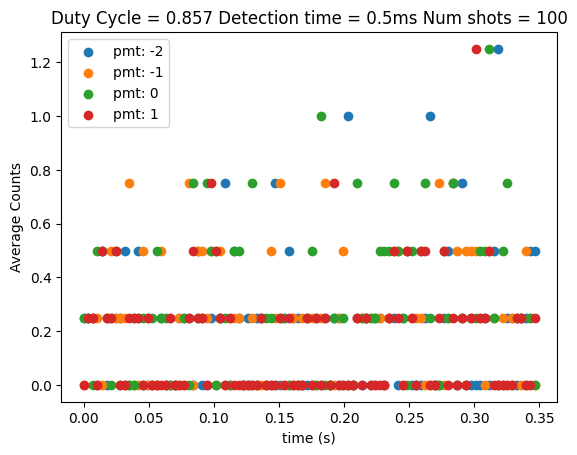

In [ ]:
for pmt_idx, vals in data.items():
    plt.scatter(times, vals, label="pmt: " + str(pmt_list[pmt_idx]))
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("Average Counts")
plt.title(f"Duty Cycle = {duty_cycle:.3f}, Detection time = {detect_time*1e3}ms, Num shots = {num_shots}")
plt.show()